In [1]:
from pyrootmemo import Parameter
from pyrootmemo.materials import MultipleRoots, Soil, Interface
from pyrootmemo.geometry import SoilProfile, FailureSurface
from pyrootmemo.models import Dram

# Dundee Root Analytical Model (DRAM)

The `DRAM` model implements the direct-shear displacement driven model by
[Meijer et al. (2022)](https://doi.org/10.1016/j.ecoleng.2022.106621).

## Create model objects

### Roots

Define some roots, using the `MultipleRoots` class. The WWM model requires the 
following root attributes to be defined:

* Root diameter: (`diameter`)
* Root tensile strength (`tensile strength`)
* Root elastic stiffness (`elastic_modulus`)
* Root tensile strenth (`tensile_strength`)

Optionally, initial (three-dimensional) root orientations can be specified. 
These are defined in a *global* coordinate system, where the $z$-axis points 
upwards (so $z$ is analogous with the surface elevation). By default, all roots
are assumed purely vertical, i.e. pointing in the z-direction.

These orientatoins can be altered by using two subsequent rotations

* Azimuth angle: (`azimuth_angle`): rotates the root around the $z$-axis (positive from $x$ to $y$)
* Azimuth angle (`elevation_angle`): rotates the root around the (now rotated) $y$-axis (positive from $z$ to $x$)

The initial root orientation for each root is thus uniquely described by a vector:

$$ \begin{bmatrix} \cos\alpha \sin\beta \\ \sin\alpha \sin\beta \\ \cos\beta \end{bmatrix} $$

where $\alpha$ is the azimuth angle and $\beta$ the elevation angle.

To account for root slippage, define the root length:

* Root length: (`length`): Twice the distance between the shearzone and the root
tip

DRAM can account for elasto-plastic roots. Define:

* Root plastic stiffness: (`plastic_modulus`). This must be lower than the elastic stiffness (`elastic_modulus`)
* Root yield strength (`yield_strength`). This must be lower than the tensile strength (`tensile_strength`)




In [2]:
roots = MultipleRoots(
    species = 'test_species',
    diameter = Parameter([1, 2, 3, 4], 'mm'),
    length = Parameter([1, 1, 1, 1], 'm'),
    elastic_modulus = Parameter([600, 500, 400, 300], 'MPa'),
    plastic_modulus = Parameter([200, 100, 100, 100], 'MPa'),
    tensile_strength = Parameter([50, 30, 10, 8], 'MPa'),
    yield_strength = Parameter([35, 20, 8, 6], 'MPa'),
    azimuth_angle = Parameter([0, 0, 0, 0], 'degrees'),
    elevation_angle = Parameter([0, 10, 20, 30], 'degrees')
    )

### Soil

Create a soil profile, consisting of one or more soils. For example, at 20 m
thick sand deposit with a water table at 10 m depth. Both unit weights and soil
strength parameters (cohesion, friction angles) are required so that the soil
shear strength at the shear plane can be estimated.

In [3]:
sand = Soil(
    'sand',
    unit_weight_bulk = Parameter(20, 'kN/m^3'),
    cohesion = Parameter(1, 'kPa'),
    friction_angle = Parameter(30, 'degrees')
    )

profile = SoilProfile(
    [sand],
    depth = Parameter([20], 'm'),
    groundwater_table = Parameter(10, 'm')
    )


### Soil-root interface

The strength of the interface between soil and roots needs to be defined. This 
is done through an `Interface` object:

In [4]:
interface = Interface(
    shear_strength = Parameter(50, 'kPa')
    )

### Failure surface

Finally, define a failure surface, which needs a cross-sectional area 
(`cross_sectional_area`), failure plane depth (`depth`), and an initial 
shear zone thickness (`shear_zone_thickness`). 

DRAM allows the shearzone to grow in thickness during shearing, as observed in
experiments. An optional maximum shear zone thickness can be defined using the 
`max_shear_zone_thickness` argument.

By default, the failure surface is assumed to be horizontal (so the global 
$z$-direction is perpendicular to the failure surface) and is assumed to move
in the global $x$-direction. 

These directions and orientations can be changed by using the optional 
`azimuth_angle` and `elevation_angle` arguments. The azimuth rotates the global 
coordinate system around the global $z$-axis (positive from $x$ to $y$). 
The elevation angle subsequent rotates the (now-rotated) coordinate system 
further by rotating around the (now-rotated) $y$-axis (positive from $z$ to
$x$). 

For the geologists among you, `azimuth` is equal to the negative value of the 
strike angle (assuming $x$ points east and $y$ points north), and `elevation` 
is equal to the dip angle. The sliding mass moves in the direction of the 
(largest) dip.

In [5]:
surface = FailureSurface(
    cross_sectional_area = Parameter(0.001, 'm^2'),
    depth = Parameter(5.0, 'm'),
    shear_zone_thickness = Parameter(10.0, 'mm'),
    #max_shear_zone_thickness = Parameter(300, 'mm'),
    azimuth_angle = Parameter(0, 'degrees'),
    elevation_angle = Parameter(20, 'degrees')
    )

### Model

With these root and soil geometry objects created, finally create the 
object describing the model.

Optionally, you specify a Weibull failure to make individual roots break 
gradually rather than catastropically, simiar to the RBMw model.

In [6]:
dram = Dram(roots, interface, profile, surface,
            weibull_shape = 8.0)

By default, the most sophisticated model is selected that can be supported by 
the available user input.

* breakage is included when the `MultipleRoots` object has been assigned a `tensile_strength` attribute.
* slipping is included when the `MultipleRoots` have been assigned a `length` attribute.
* elasto-plasticity is included when the `MultipleRoots` have been assigned both a `plastic_modulus` and `yield_strength` attribute
* weibull failure is included when a Weibull shape parameter is define when creating the Waldron class, using the `weibull_shape' input argument.

You can check what behaviour is allowed by querying the `breakage`, `slippage`
and/or the `elastoplastic` attributes of the model class.

In [7]:
print(dram.breakage)
print(dram.slipping)
print(dram.elastoplastic)

True
True
True


If you want to fix a specific type of behaviour, you can force certain behaviour 
when creating the model. For example, to disable root breakage:


In [8]:
dram_simplified = Dram(roots, interface, profile, surface, 
                       breakage = True, slipping = False, elastoplastic = False)

## Calculations

Various calculations can be made. The method calculated results are returned
depends on the "results" input argument that can be defined for each calculation
function:

* `results = "attribute"` (default behaviour): calculated model results are 
stored in a dictionary in the `output` attribute of the class.
* `results = "return"`: functions returns a dictionary with results, without 
writing to class' `output` attribute
* `results = "both"`: functions both returns dictionary output *and* writes 
to the `output` attribute.
 
### Reinforcement at specified displacement (`calc_peak_force()`)

In [9]:
max_displacement = Parameter(1000.0, 'mm')
dram.calc_reinforcement(max_displacement, n = 100)

print(dram.output['displacement'])
print(dram.output['reinforcement'])
print(dram.output['shear_zone_thickness'])

[0.0 10.1010101010101 20.2020202020202 30.3030303030303 40.4040404040404 50.505050505050505 60.6060606060606 70.7070707070707 80.8080808080808 90.9090909090909 101.01010101010101 111.1111111111111 121.2121212121212 131.3131313131313 141.4141414141414 151.5151515151515 161.6161616161616 171.7171717171717 181.8181818181818 191.91919191919192 202.02020202020202 212.1212121212121 222.2222222222222 232.3232323232323 242.4242424242424 252.5252525252525 262.6262626262626 272.7272727272727 282.8282828282828 292.9292929292929 303.030303030303 313.1313131313131 323.2323232323232 333.3333333333333 343.4343434343434 353.5353535353535 363.6363636363636 373.73737373737373 383.83838383838383 393.93939393939394 404.04040404040404 414.1414141414141 424.2424242424242 434.3434343434343 444.4444444444444 454.5454545454545 464.6464646464646 474.7474747474747 484.8484848484848 494.9494949494949 505.050505050505 515.1515151515151 525.2525252525252 535.3535353535353 545.4545454545454 555.5555555555555 565.656

c:\Users\gjm36\AppData\Local\miniforge3\envs\rrmm\Lib\site-packages\matplotlib\cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


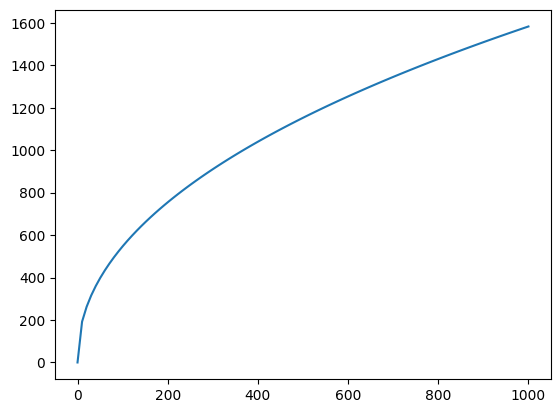

In [10]:
import matplotlib.pyplot as plt
plt.plot(dram.output['displacement'], dram.output['reinforcement'])

The function also returns some information about the type of root behaviour.
The types and the fraction of total root cross-sectional area that behaves 
according to each type can be accessed by:

In [11]:
#print(waldron.output['behaviour_types'])
#print(waldron.output['behaviour_fraction'])

### Peak reinforcement (`calc_peak_reinforcement()`)

To calculat the peak reinforcement, as well as the level of shear displacement 
at which this occurs, first call the `calc_peak_reinforcement()` function and
then request the results from the model's `output` dictionary.

In [12]:
dram.calc_peak_reinforcement()

print(dram.output['peak_displacement'])
print(dram.output['peak_reinforcement'])

c:\Users\gjm36\AppData\Local\miniforge3\envs\rrmm\Lib\site-packages\numpy\_core\function_base.py:163: RuntimeWarning: invalid value encountered in multiply
  y *= step
c:\Users\gjm36\AppData\Local\miniforge3\envs\rrmm\Lib\site-packages\pint\facets\plain\quantity.py:1006: RuntimeWarning: invalid value encountered in divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)
c:\Users\gjm36\AppData\Local\miniforge3\envs\rrmm\Lib\site-packages\pint\facets\plain\quantity.py:1006: RuntimeWarning: invalid value encountered in multiply
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


inf millimeter
nan kilopascal


In [13]:
from pyrootmemo.helpers import units
max(5 * units('mm'), 4 * units('m'))

<Quantity(4, 'meter')>

## Plotting (`plot()`)

The results of the Waldron model can be plotted using the `plot()` method.

To create a basic plot:

In [14]:
dram.plot(peak = False)

AttributeError: 'FailureSurface' object has no attribute 'max_shear_zone_thickness'

To show the contributions of each individual root:

<Axes: xlabel='Shear displacement [mm]', ylabel='Reinforcement [kPa]'>

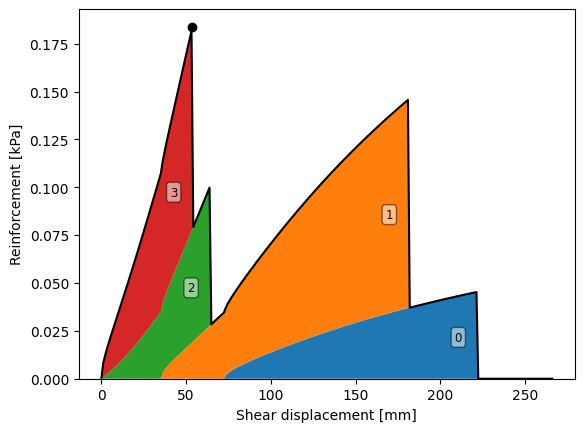

In [ ]:
waldron.plot(stack = True)

You can see that the first two roots do not mobilise any resistance until some
shear displacement has occured. This is because of their initial orientation,
relative to the defined failure surface, is initially unfavourable for
developing tension.